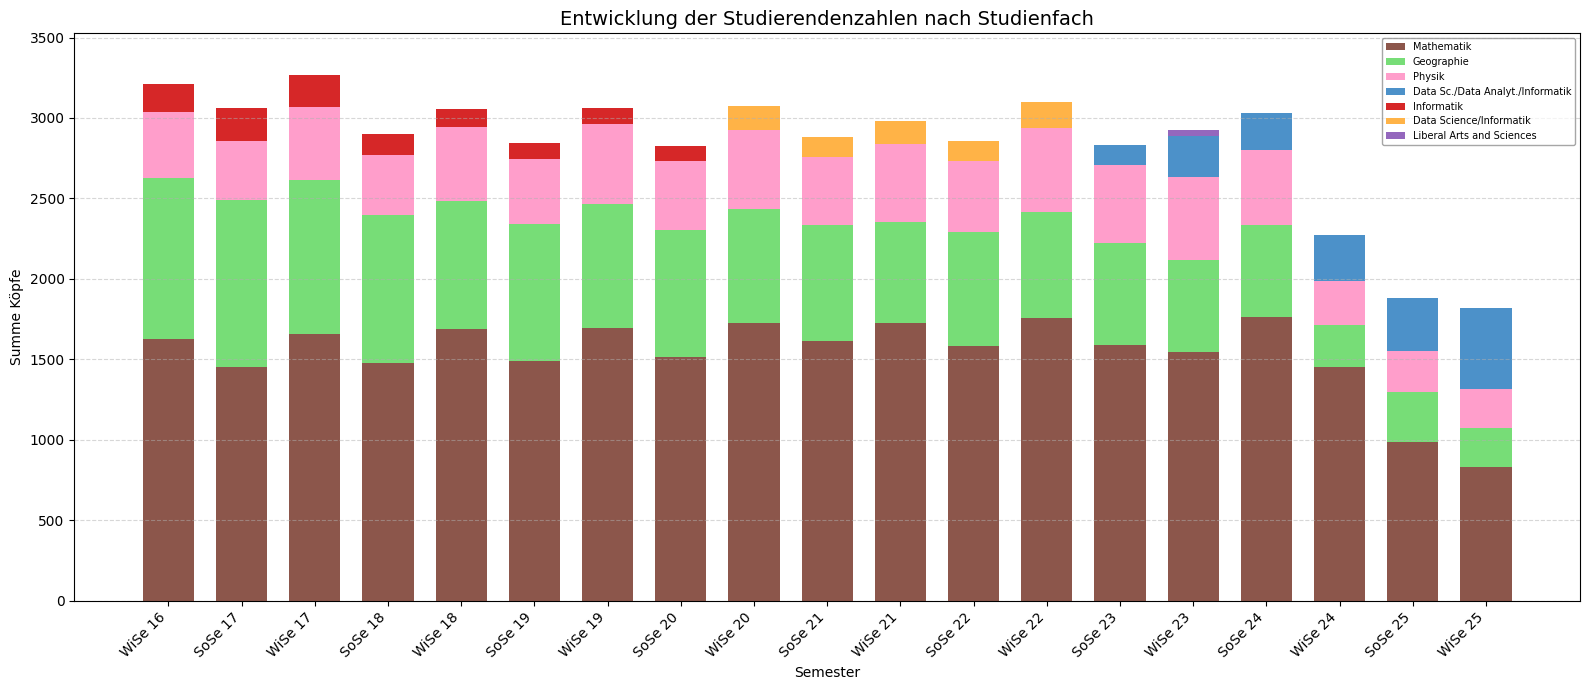

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv(r"C:\Users\Ich\Documents\Uni\Visualisierung\Projekt\data_excels\Studierende insgesamt(inclu. Beurlaubte)\Studierende insgesamt.csv")
df2 = pd.read_csv(r"C:\Users\Ich\Documents\Uni\Visualisierung\Projekt\data_excels\wise24 - wise25\Gesamt_mB_Köpfe.csv")

# Relevante Spalten
df1 = df1[['Studienfach', 'Summe_Koepfe', 'Jahr', 'Semester']].copy()
df2 = df2[['Studienfach', 'Summe_Koepfe', 'Jahr', 'Semester']].copy()

# Schreibweisen harmonisieren
df1['Studienfach'] = df1['Studienfach'].replace({
    'Geograph./Erdk.': 'Geographie'
})

df2['Studienfach'] = df2['Studienfach'].replace({
    'mathematik': 'Mathematik',
    'physik': 'Physik',
    'geographie': 'Geographie',
    'informatik': 'Informatik',
    'data science': 'Data Science',
    'data analytics': 'Data Analytics'
})

# Überlappende Semester aus df1 entfernen
mask_overlap = (
    ((df1['Jahr'] == 2024) & (df1['Semester'] == 'Winter')) |
    ((df1['Jahr'] == 2025) & (df1['Semester'].isin(['Sommer', 'Winter'])))
)
df1_clean = df1[~mask_overlap].copy()

# Neuere Daten: WiSe24 bis WiSe25 zusammenführen
df2_step = df2.copy()

target_all_three = {
    (2024, 'Winter'),
    (2025, 'Sommer'),
    (2025, 'Winter')
}

mask_all_three = (
    df2_step['Studienfach'].isin(['Informatik', 'Data Science', 'Data Analytics']) &
    df2_step[['Jahr', 'Semester']].apply(lambda r: (int(r['Jahr']), r['Semester']), axis=1).isin(target_all_three)
)

rows_all_three = df2_step[mask_all_three]
rows_keep = df2_step[~mask_all_three]

merged_all_three = (
    rows_all_three
    .groupby(['Jahr', 'Semester'], as_index=False)['Summe_Koepfe']
    .sum()
)
merged_all_three['Studienfach'] = 'Data Sc./Data Analyt./Informatik'

df2_final = pd.concat([rows_keep, merged_all_three], ignore_index=True)

# Datensätze kombinieren
df = pd.concat([df1_clean, df2_final], ignore_index=True).reset_index(drop=True)

# Semester-Labels
semester_order = {'Sommer': 1, 'Winter': 2}

def format_semester(row):
    year = str(int(row['Jahr']))[-2:]
    return f"WiSe {year}" if row['Semester'] == 'Winter' else f"SoSe {year}"

df['Sem_Label'] = df.apply(format_semester, axis=1)
df['Sem_Order'] = df['Jahr'].astype(int) * 10 + df['Semester'].map(semester_order)

# Features exakt wie im Ausgangsbild
desired_features = [
    'Data Sc./Data Analyt./Informatik',
    'Data Science/Informatik',
    'Geographie',
    'Informatik',
    'Liberal Arts and Sciences',
    'Mathematik',
    'Physik'
]

# Pivot
df_plot = df.sort_values('Sem_Order').pivot_table(
    index=['Sem_Order', 'Sem_Label'],
    columns='Studienfach',
    values='Summe_Koepfe',
    aggfunc='sum'
).reset_index()

# Fehlende Features ergänzen
for feat in desired_features:
    if feat not in df_plot.columns:
        df_plot[feat] = 0

df_plot = df_plot[['Sem_Order', 'Sem_Label'] + desired_features]

labels = df_plot['Sem_Label']
x = np.arange(len(labels))

# Größte Kategorien unten
feature_sums = df_plot[desired_features].fillna(0).sum(axis=0).sort_values(ascending=False)
stack_order = feature_sums.index.tolist()

# Neues color map
color_map = {
    'Data Sc./Data Analyt./Informatik': '#4c91c9',
    'Data Science/Informatik': '#ffb347',
    'Geographie': '#77dd77',
    'Informatik': '#d62728',
    'Liberal Arts and Sciences': '#9467bd',
    'Mathematik': '#8c564b',
    'Physik': '#ff9ecb'
}

fig, ax = plt.subplots(figsize=(16, 7))

bottom = np.zeros(len(x))
bar_handles = {}
for fach in stack_order:
    values = df_plot[fach].fillna(0).values
    bars = ax.bar(
        x, values, bottom=bottom, label=fach, width=0.7,
        color=color_map[fach]
    )
    bar_handles[fach] = bars[0]
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Entwicklung der Studierendenzahlen nach Studienfach', fontsize=14)
ax.set_ylabel('Summe Köpfe')
ax.set_xlabel('Semester')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Legende wie im ursprünglichen Bild
legend_order = desired_features
handles = [bar_handles[f] for f in legend_order if f in bar_handles]
legend_labels = [f for f in legend_order if f in bar_handles]
ax.legend(
    loc='upper right',        # Position dans le graphique
    fontsize=7,              # Texte plus petit
    ncol=1,                  # 1 colonnes pour compacter
    framealpha=0.7,          # Fond semi-transparent
    edgecolor='gray'
)

# Mehr Luft nach oben
ymax = bottom.max()
ax.set_ylim(0, ymax * 1.08)

plt.tight_layout()
plt.show()